# Lab 3 — Oscillator Simulation

**Name:** Matthew Nallar  
**Date:** September 13, 2026

In [66]:
import numpy as np
import matplotlib.pyplot as plt

In [67]:
def simulate_sho(method, v0=0, dt=0.05, k=1, n_periods=10):
    
    t = 0.0
    x = 1.0
    x0 = x                 # Save initial position
    vx = v0
    m = 1.0

    omega0 = np.sqrt(k / m)
    T = 2 * np.pi / omega0
    t_max = n_periods * T

    # Exact solution
    t_exact = np.linspace(0, t_max, 2000)
    exact_x = x0 * np.cos(omega0 * t_exact)
    exact_vx = -x0 * omega0 * np.sin(omega0 * t_exact)

    # Initial energy
    KE = 0.5 * m * vx**2
    PE = 0.5 * k * x**2
    E_total = KE + PE

    # Storage lists
    t_arr = [t]
    x_arr = [x]
    vx_arr = [vx]
    KE_arr = [KE]
    PE_arr = [PE]
    E_total_arr = [E_total]

    # Integration loop
    while t < t_max:

        # Acceleration
        ax = -(k / m) * x

        if method == "euler":
            vx_old = vx
            vx = vx + ax * dt
            x = x + vx_old * dt

        elif method == "euler-cromer":
            vx = vx + ax * dt
            x = x + vx * dt

        t += dt

        # Energy
        KE = 0.5 * m * vx**2
        PE = 0.5 * k * x**2
        E_total = KE + PE

        # Store numerical results
        t_arr.append(t)
        x_arr.append(x)
        vx_arr.append(vx)
        KE_arr.append(KE)
        PE_arr.append(PE)
        E_total_arr.append(E_total)

    return (
        np.array(t_arr),
        np.array(x_arr),
        np.array(vx_arr),
        np.array(KE_arr),
        np.array(PE_arr),
        np.array(E_total_arr),
        t_exact,
        exact_x,
        exact_vx
    )

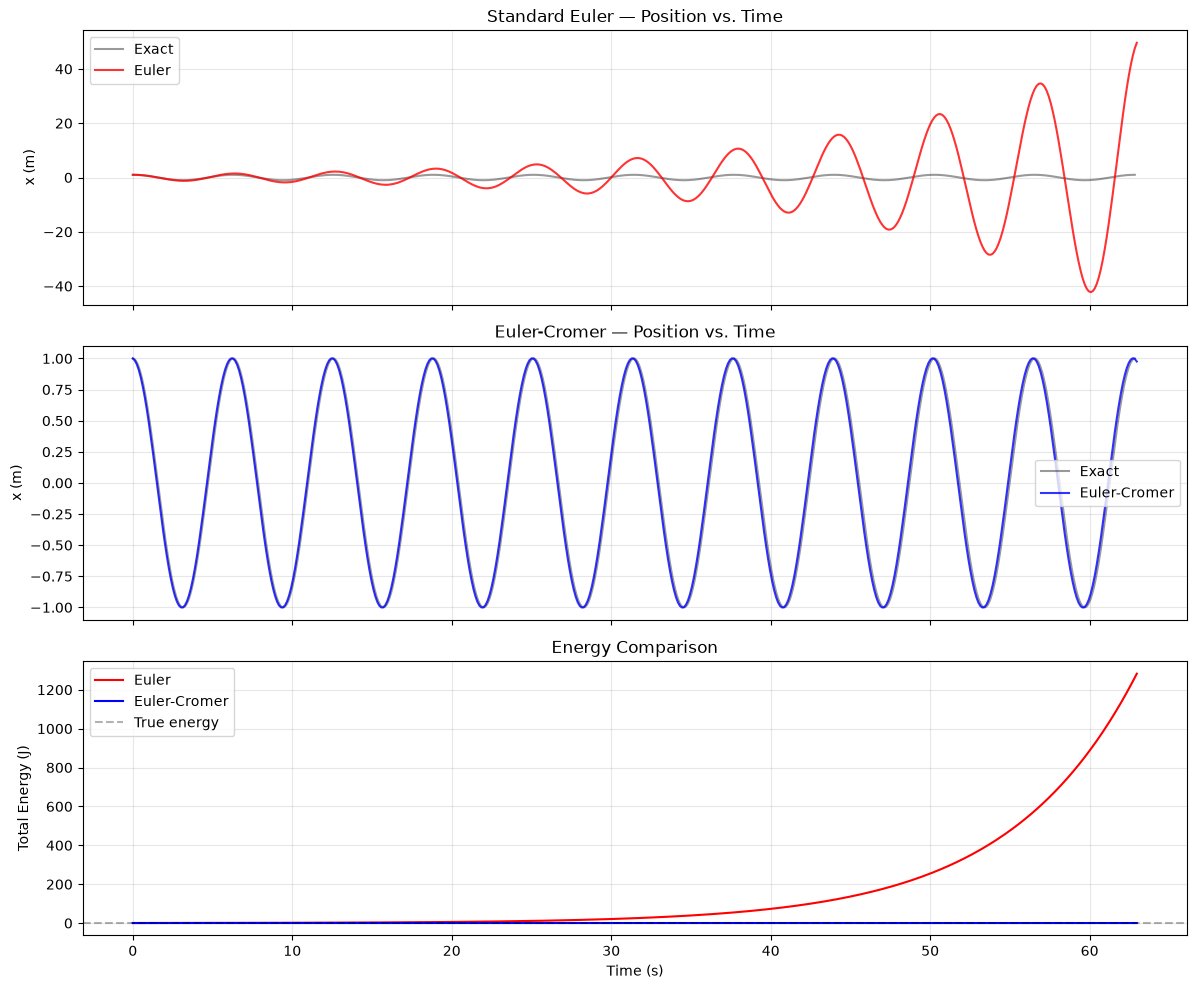

In [68]:
k = 1
m = 1

omega0 = np.sqrt(k / m)
T = 2 * np.pi / omega0
dt = T / 50

t_e, x_e, v_e, KE_e, PE_e, E_e, t_exact, exact_x, exact_vx = simulate_sho(
    method="euler",
    v0=0,
    dt=dt
)

t_ec, x_ec, v_ec, KE_ec, PE_ec, E_ec, _, _, _ = simulate_sho(
    method="euler-cromer",
    v0=0,
    dt=dt
)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(t_exact, exact_x, 'k-', alpha=0.4, label='Exact')
axes[0].plot(t_e, x_e, 'r-', alpha=0.8, label='Euler')
axes[0].set_ylabel('x (m)')
axes[0].set_title('Standard Euler — Position vs. Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_exact, exact_x, 'k-', alpha=0.4, label='Exact')
axes[1].plot(t_ec, x_ec, 'b-', alpha=0.8, label='Euler-Cromer')
axes[1].set_ylabel('x (m)')
axes[1].set_title('Euler-Cromer — Position vs. Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_e, E_e, 'r-', label='Euler')
axes[2].plot(t_ec, E_ec, 'b-', label='Euler-Cromer')
axes[2].axhline(y=E_e[0], color='k', linestyle='--', alpha=0.3, label='True energy')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Total Energy (J)')
axes[2].set_title('Energy Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 The Euler amplitude increases with each period, and its energy increases exponentially, creating energy which is not physically possible. Euler-Cromer keeps the same amplitude throughout and energy remains around same, the Euler-Cromer method does not gain error for every cycle.

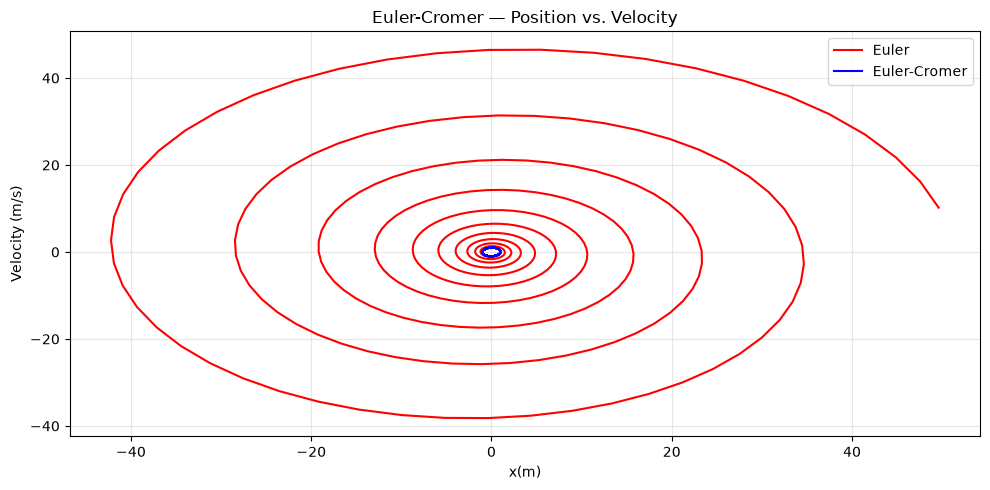

In [69]:
k = 1
m = 1

omega0 = np.sqrt(k / m)
T = 2 * np.pi / omega0
dt = T / 50

t_e, x_e, v_e, KE_e, PE_e, E_e, t_exact, exact_x, exact_vx = simulate_sho(
    method="euler",
    v0=0,
    dt=dt
)

t_ec, x_ec, v_ec, KE_ec, PE_ec, E_ec, _, _, _ = simulate_sho(
    method="euler-cromer",
    v0=0,
    dt=dt
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_e, v_e, 'r-', label='Euler')
ax.plot(x_ec, v_ec, 'b-', label='Euler-Cromer')
ax.set_xlabel('x(m)')
ax.set_ylabel('Velocity (m/s)')
ax.set_title('Euler-Cromer — Position vs. Velocity')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**What does the Euler curve do? What does the Euler-Cromer curve do? Connect the shape to what you saw in the energy plot.**

The Euler graph exhibits an outward spiral behaior, conveying a system gaining energy over time which is consistent with the energy graph. The Euler-Cromer curve is a closed loop circle, which means the system repeats the exact same sequence of states indefinitely.

In [70]:
def simulate_sho_damp(v0=0, dt=0.05, k=1, n_periods=10, b=12):
    
    t = 0.0
    x = 1.0
    x0 = x                 # Save initial position
    vx = v0
    m = 1.0

    omega0 = np.sqrt(k / m)
    T = 2 * np.pi / omega0
    t_max = n_periods * T


    # Storage lists
    t_arr = [t]
    x_arr = [x]
    vx_arr = [vx]

    # Integration loop
    while t < t_max:

    # Acceleration
        ax = (-(k / m) * x) - (b/m) * vx

        vx = vx + ax * dt
        x = x + vx * dt

        t += dt

        # Store numerical results
        t_arr.append(t)
        x_arr.append(x)
        vx_arr.append(vx)

    return (
        np.array(t_arr),
        np.array(x_arr),
        np.array(vx_arr),
    )

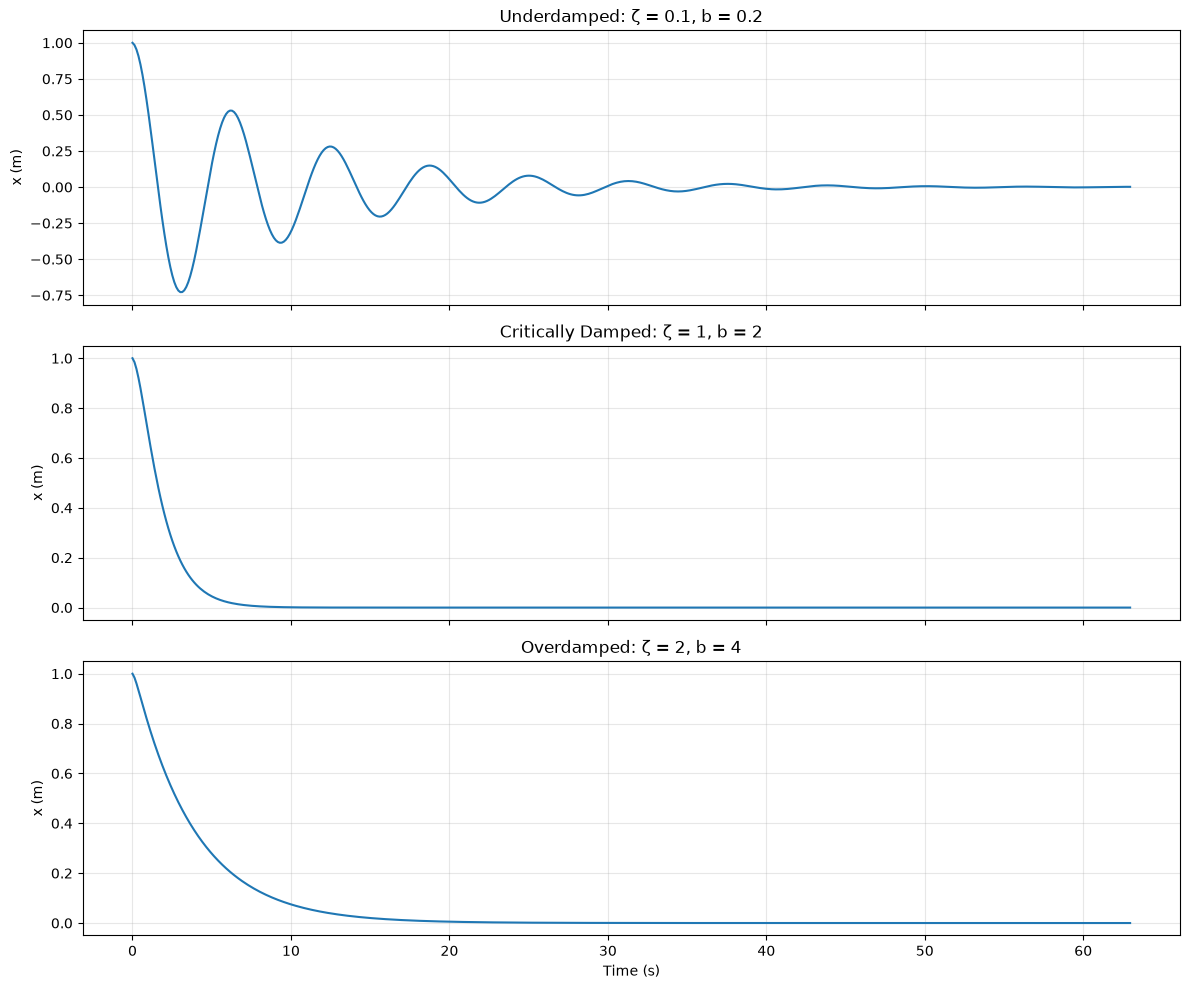

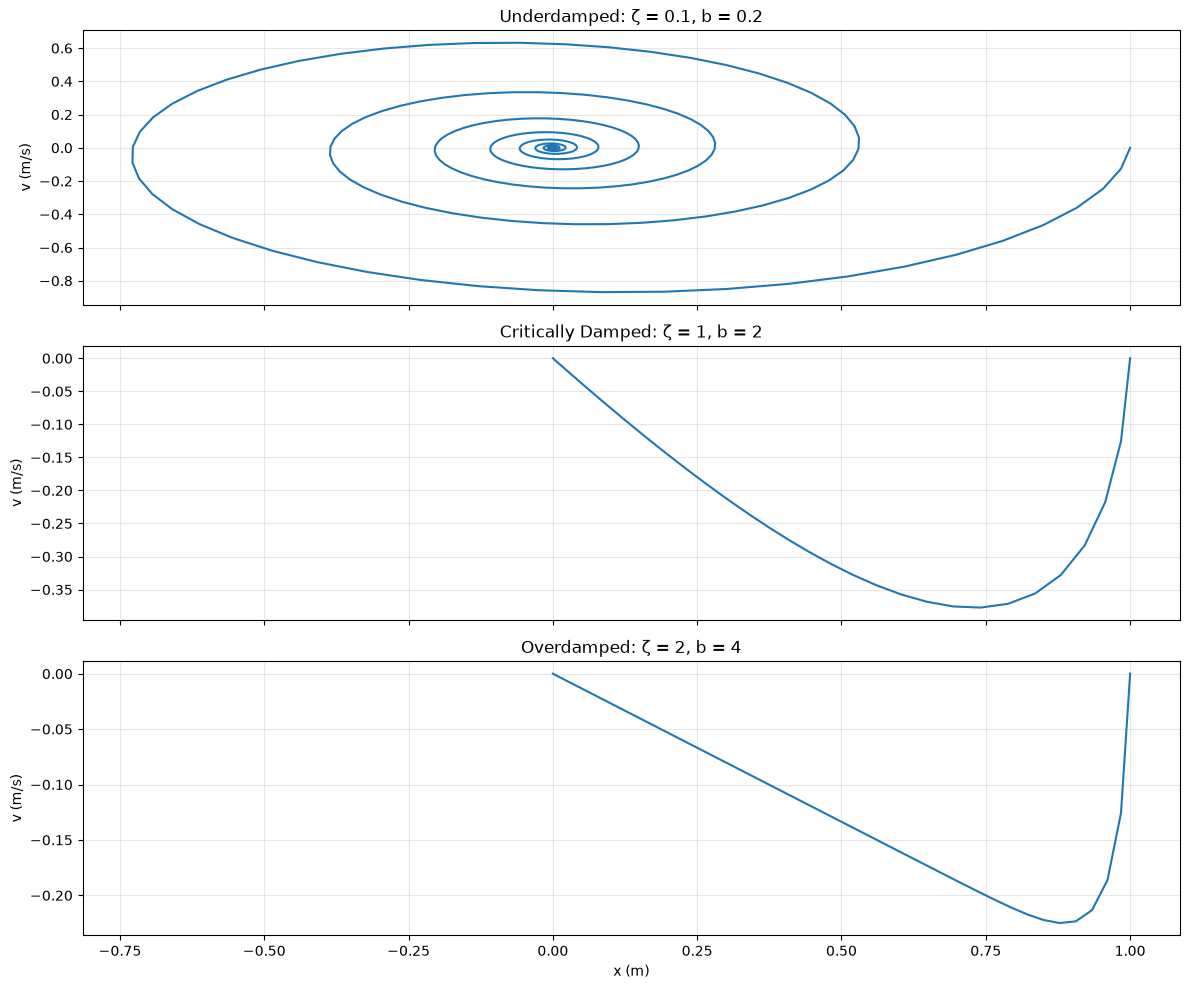

In [71]:
# Underdamped: zeta = 0.1
k = 1
m = 1

omega0 = np.sqrt(k / m)
T = 2 * np.pi / omega0

dt = T / 50

t_under, x_under, v_under = simulate_sho_damp(
    b=0.2, dt=dt, k=k
)

# Critical: zeta = 1
t_critical, x_critical, v_critical = simulate_sho_damp(
    b=2, dt=dt, k=k
)

# Overdamped: zeta = 2
t_over, x_over, v_over = simulate_sho_damp(
    b=4, dt=dt, k=k
)


fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(t_under, x_under)
axes[0].set_ylabel('x (m)')
axes[0].set_title('Underdamped: ζ = 0.1, b = 0.2')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_critical, x_critical)
axes[1].set_ylabel('x (m)')
axes[1].set_title('Critically Damped: ζ = 1, b = 2')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_over, x_over)
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('x (m)')
axes[2].set_title('Overdamped: ζ = 2, b = 4')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(x_under, v_under)
axes[0].set_ylabel('v (m/s)')
axes[0].set_title('Underdamped: ζ = 0.1, b = 0.2')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_critical, v_critical)
axes[1].set_ylabel('v (m/s)')
axes[1].set_title('Critically Damped: ζ = 1, b = 2')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x_over, v_over)
axes[2].set_xlabel('x (m)')
axes[2].set_ylabel('v (m/s)')
axes[2].set_title('Overdamped: ζ = 2, b = 4')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpreting the phase-space plot: How does each regime spiral toward the origin differently?**

Underdamped conveys that energy is lost slower, shown by the inward spiral behavior. Critically damped shows a single round stroke to rest, and much quicker loss of energy. Overdamped has the sharpest and quickest path to rest.

In [72]:
def simulate_sho_drive_1(omega_d, F0=1.0, b=0.2, v0=0,
                       dt=0.05, k=1, m=1, n_periods=50):

    t = 0.0
    x = 1.0
    vx = v0

    T_drive = 2 * np.pi / omega_d
    t_max = n_periods * T_drive

    t_arr = [t]
    x_arr = [x]
    vx_arr = [vx]

    while t < t_max:

        # Acceleration
        ax = -(k / m) * x - (b / m) * vx \
             + (F0 / m) * np.cos(omega_d * t)

        # Euler-Cromer
        vx = vx + ax * dt
        x = x + vx * dt

        t += dt

        t_arr.append(t)
        x_arr.append(x)
        vx_arr.append(vx)

    return np.array(t_arr), np.array(x_arr), np.array(vx_arr)

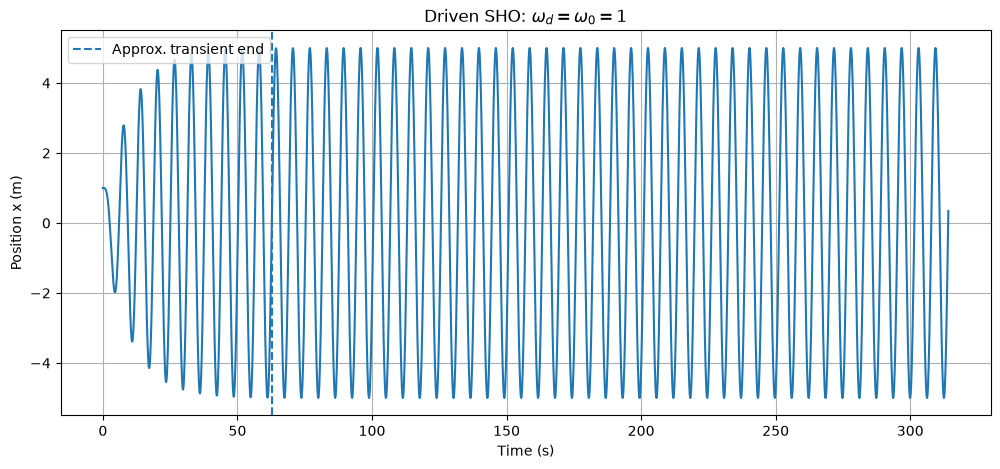

In [ ]:
omega_d = 1.0

t, x, v = simulate_sho_drive_1(
    omega_d=omega_d,
    F0=1.0,
    b=0.2,
    dt=dt,
    k=1,
    m=1,
    n_periods=50
)

plt.figure(figsize=(12, 5))

plt.plot(t, x)

# Approximate end of transient (talk about this)
plt.axvline(10 * 2 * np.pi, linestyle='--',
            label='Approx. transient end')

plt.xlabel('Time (s)')
plt.ylabel('Position x (m)')
plt.title(r'Driven SHO: $\omega_d = \omega_0 = 1$')
plt.legend()
plt.grid(True)
plt.show()

**Point out where the transient ends and steady state begins.**

Using the period equation T = 2π/ω, where ω is the natural frequency of 1, 2π = 6.28. For ten period cycles however, 6.28*10 = 62.8 is the approximate time where the transient behavior ends.

In [74]:
def simulate_sho_drive_2(omega_d, F0=1.0, b=0.2, v0=0, dt=0.05,
                       k=1, m=1, n_periods=100):

    t = 0.0
    x = 1.0
    vx = v0

    omega0 = np.sqrt(k / m)
    T_drive = 2 * np.pi / omega_d
    t_max = n_periods * T_drive

    t_arr = [t]
    x_arr = [x]
    vx_arr = [vx]

    while t < t_max:

        # Acceleration
        ax = -(k / m) * x - (b / m) * vx \
             + (F0 / m) * np.cos(omega_d * t)

        # Euler-Cromer
        vx = vx + ax * dt
        x = x + vx * dt

        t += dt

        t_arr.append(t)
        x_arr.append(x)
        vx_arr.append(vx)

    return np.array(t_arr), np.array(x_arr), np.array(vx_arr)

Peak amplitude = 4.972
Peak frequency = 1.008


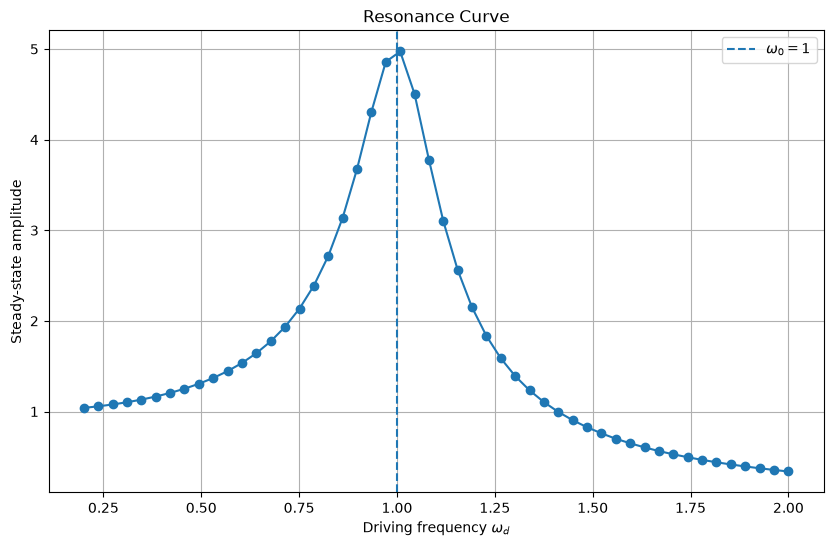

In [75]:
omega_values = np.linspace(0.2, 2.0, 50)
amplitudes = []

for omega_d in omega_values:

    t, x, v = simulate_sho_drive_2(
        omega_d=omega_d,
        F0=1.0,
        b=0.2,
        dt=dt,
        k=1,
        m=1,
        n_periods=100
    )

    # Driving period
    T_drive = 2 * np.pi / omega_d

    # Look only at the final 5 driving periods
    t_start = t[-1] - 5 * T_drive
    steady_state = x[t >= t_start]

    # Steady-state amplitude
    amplitude = np.max(np.abs(steady_state))
    amplitudes.append(amplitude)


# Find the numerical resonance frequency
peak_index = np.argmax(amplitudes)
omega_peak = omega_values[peak_index]

print(f"Peak amplitude = {amplitudes[peak_index]:.3f}")
print(f"Peak frequency = {omega_peak:.3f}")


# Plot
plt.figure(figsize=(10, 6))
plt.plot(omega_values, amplitudes, 'o-')
plt.axvline(1.0, linestyle='--', label=r'$\omega_0 = 1$')

plt.xlabel(r'Driving frequency $\omega_d$')
plt.ylabel('Steady-state amplitude')
plt.title('Resonance Curve')
plt.legend()
plt.grid(True)
plt.show()

**Interpreting the resonance curve: Why does the amplitude peak near ω₀? What would happen to the peak height if you reduced the damping?**

A driving freqency equal to 1, the same as the natural frequency of the system, the stiffness and inertial forces are balanced, allowing the amplitude caused by the driving force to be larger. Reducing damping, more specifically by decreasing the value of b, would increase the amplitude. The less damping, the less resistance there is to a larger ampltiude for oscillations.